# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [15]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error

### Step 1. Load the data

In [43]:
df=pd.read_csv("../../content/datasets/Salary Data.csv")

In [68]:
df.head(12)

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.5,48266
7,2.9,56642
8,3.0,60150
9,3.2,54445


### Step 2.a Assign variables `X` to the features and `y` to the target

In [82]:
x = df[["Experience Years"]]
y = df["Salary"]

### Step 2.b print the type of each

In [83]:
print(type(x))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [84]:
# the target is numeric and the task is regression 

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [85]:
print(x.shape)
print(y.shape)

(40, 1)
(40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [86]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

Text(0.5, 1.0, 'Experience vs Salary')

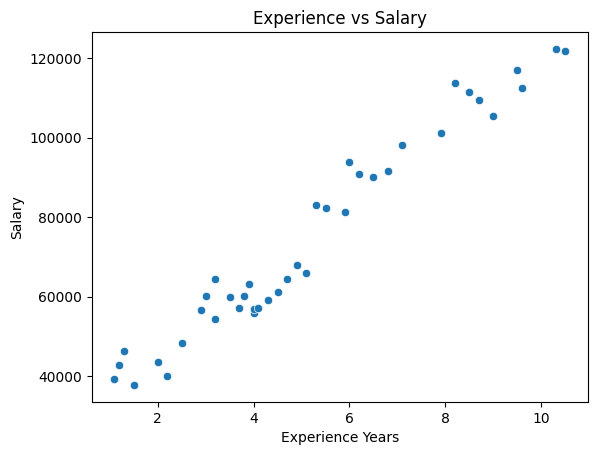

In [87]:
sns.scatterplot(x="Experience Years", y="Salary", data=df)
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience vs Salary")

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [88]:
# is we see in the plot  is increasing  but we whave a smail decrease  in 1.5 years 


### Step 7. Initialize a regression model

In [89]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [90]:
x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size=0.2, random_state=42 )   

### Step 9.a Train the model on the training set

In [100]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [101]:
slope = model.coef_
intercept = model.intercept_
print( "Slope:" , slope)
print("Intercept: ", intercept)

Slope: [9408.03127251]
Intercept:  26716.25017614555


### Step 9.c how much salary does a person get with 2 years of experience?

In [102]:
model.predict([[2]])

/Users/mafahad/Desktop/ai sdaia/B5/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([45532.31272116])

### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [103]:
increase = model.coef_[0] * 0.5
print("Salar for 6 month :",increase)

Salar for 6 month : 4704.015636253289


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [104]:
print("Salary 0 Expreience :", model.intercept_)

Salary 0 Expreience : 26716.25017614555


### Step 10. Evaluate the model on the test set

In [96]:
y_pred = model.predict(x_test)
y_tr = model.predict(x_train)

print("Test MSE :",mean_squared_error(y_test,y_pred))
print("Train MSE :",mean_squared_error(y_train,y_tr))


Test MSE : 48077731.169193596
Train MSE : 24546972.15501059


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [97]:
x_sample = x_test.iloc[:3]
y_sample = y_test.iloc[:3]

pre = model.predict(x_sample)
print("prefiction ",pre)
print("actual ",y_sample.values)


prefiction  [69052.39090243 64348.37526617 64348.37526617]
actual  [61111 56957 55794]


### Step 12. Plot the data and the regression line

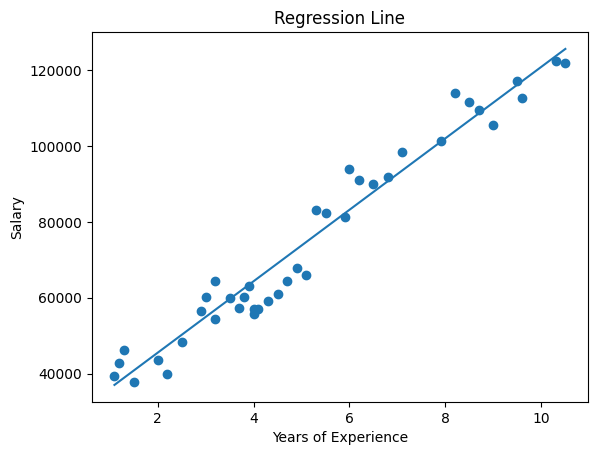

In [110]:
plt.scatter(x,y)
plt.plot(x,model.predict(x))

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Regression Line")
plt.show()